# 고령 취약계층 헬스케어 수요 예측 플랫폼
## EDA (Exploratory Data Analysis)

**분석 대상**: `df_analysis_v6.csv` — 서울시 행정동별 고령화·의료 인프라 통합 데이터 (2023년 기준, 420 행정동)

**EDA 목표**
1. Y변수(`요양수요가속도`)의 분포 특성 파악 → 회귀 모델 전처리 방향 결정
2. X변수 9개의 분포 및 이상치 탐지
3. X↔Y 상관 구조 확인 → Feature 중요도 사전 검토
4. 자치구별 공간 패턴 탐색
5. 트랙 B(분류)·C(군집화) 준비를 위한 라벨링 전략 수립

---

| 구분 | 변수명 | 설명 |
|------|--------|------|
| ID | 행정동코드, 행정동명, 시군구명, 자치구명, 연도 | 식별자 |
| ID | 총인구수, 65세이상인구, 독거노인수_2018 | 규모 참조값 |
| X1 | 고령화율 | 65세이상 / 총인구 × 100 |
| X2 | 고령화율_변화 | 2022→2023 고령화율 증가분 |
| X3 | 독거노인비율 | 독거노인 / 65세이상 × 100 |
| X4 | 비율_75-79세 | 75~79세 / 65세이상 × 100 |
| X5 | 비율_85세이상 | 85세+ / 65세이상 × 100 |
| X6 | 인프라갭 | 65세이상 / (의료기관수+1) |
| X7 | 포화도 | 요양시설 현원/정원 |
| X8 | 시설수 | 자치구 내 요양시설 수 |
| X9 | 수요공급갭지수 | NHIS 가중 미충족 수요 |
| **Y** | **요양수요가속도** | **ln(독거노인_2023/2018)×100** |

## 0. 환경 설정

In [56]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# 한글 폰트 설정
KOREAN_FONTS = [
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',   # 가장 선호
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
]
for fpath in KOREAN_FONTS:
    import os
    if os.path.exists(fpath):
        fm.fontManager.addfont(fpath)
        plt.rcParams['font.family'] = fm.FontProperties(fname=fpath).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

DATA_PATH = 'data/df_analysis_v6.csv'

ID_COLS   = ['행정동코드', '행정동명', '시군구명', '자치구명', '연도',
             '총인구수', '65세이상인구', '독거노인수_2018']
FEAT_COLS = ['고령화율', '고령화율_변화', '독거노인비율',
             '비율_75-79세', '비율_85세이상', '인프라갭',
             '포화도', '시설수', '수요공급갭지수']
TARGET = '요양수요가속도'

print('환경 설정 완료')

환경 설정 완료


---
## 1. 데이터 로드 및 기본 확인

In [57]:
# 데이터 로드
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# 데이터 형태 확인
print(df.shape)
print(f'({df.shape[0]}개 행정동 × {df.shape[1]}개 컬럼)')
print(df.info())

(420, 18)
(420개 행정동 × 18개 컬럼)
<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   행정동코드       420 non-null    int64  
 1   행정동명        420 non-null    str    
 2   시군구명        420 non-null    str    
 3   자치구명        420 non-null    str    
 4   연도          420 non-null    int64  
 5   총인구수        420 non-null    int64  
 6   65세이상인구     420 non-null    int64  
 7   독거노인수_2018  420 non-null    float64
 8   고령화율        420 non-null    float64
 9   고령화율_변화     420 non-null    float64
 10  독거노인비율      420 non-null    float64
 11  비율_75-79세   420 non-null    float64
 12  비율_85세이상    420 non-null    float64
 13  인프라갭        420 non-null    float64
 14  포화도         420 non-null    float64
 15  시설수         420 non-null    float64
 16  수요공급갭지수     420 non-null    float64
 17  요양수요가속도     420 non-null    float64
dtypes: float64(11), int64(4), str(3)
memory usage: 71.4

In [58]:
# 결측치 확인
missing = df.isna().sum()
missing_df = pd.DataFrame({'결측수': missing})
print('=== 결측치 현황 ===')
display(missing_df)

=== 결측치 현황 ===


,결측수
행정동코드,0
행정동명,0
시군구명,0
자치구명,0
연도,0
총인구수,0
65세이상인구,0
독거노인수_2018,0
고령화율,0
고령화율_변화,0


In [59]:
# 행정동 중복 확인
dup_count = df.duplicated(subset=['행정동코드']).sum()
print(f'행정동코드 중복: {dup_count}건')

행정동코드 중복: 0건


In [60]:
# X + Y 변수 기술통계
df[FEAT_COLS + [TARGET]].describe().round(3)

,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_85세이상,인프라갭,포화도,시설수,수요공급갭지수,요양수요가속도
count,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000
mean,18.248,0.785,27.383,18.370,8.929,2147.297,0.919,9.631,472.810,30.197
std,3.855,0.510,9.756,1.477,1.753,1514.797,0.056,5.508,279.319,20.941
min,8.210,-2.030,7.320,14.240,2.440,41.000,0.814,2.000,9.824,-24.336
25%,15.600,0.540,22.028,17.545,7.700,1013.700,0.875,6.000,277.249,19.398
50%,18.285,0.855,26.170,18.410,8.695,1733.750,0.912,9.000,396.745,28.825
75%,20.652,1.110,31.015,19.335,9.855,3000.000,0.964,12.000,613.890,38.175
max,34.830,3.090,85.920,23.900,17.940,7688.000,1.000,21.000,2020.541,114.752


---
## 2. Y 변수 분포 분석 — `요양수요가속도`

> **정의**: ln(독거노인수_2023 / 독거노인수_2018) × 100  
> 값이 클수록 2018→2023 사이 독거노인 증가 속도가 빠른 행정동

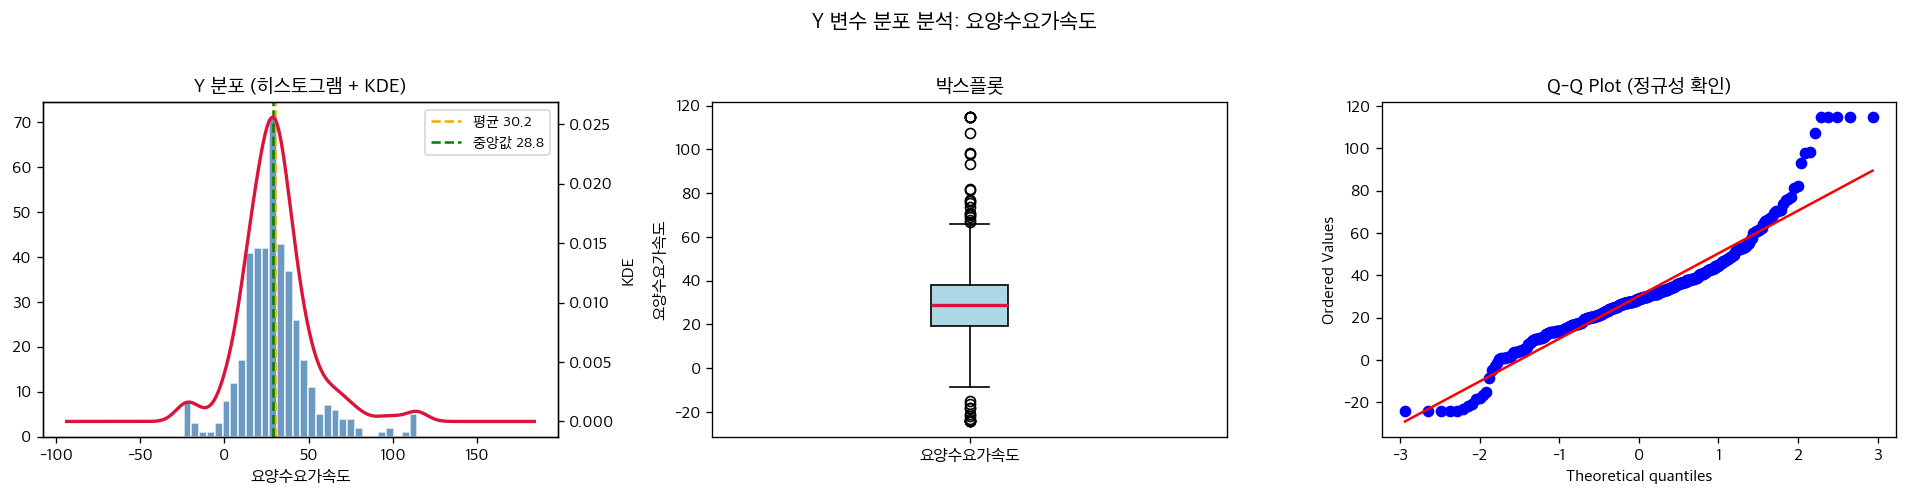

평균: 30.20 | 중앙값: 28.83 | 표준편차: 20.94
왜도(Skewness): 0.932 | 첨도(Kurtosis): 3.564


In [61]:
y = df[TARGET].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 히스토그램 + KDE
axes[0].hist(y, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax0_twin = axes[0].twinx()
y.plot.kde(ax=ax0_twin, color='crimson', linewidth=2)
ax0_twin.set_ylabel('KDE')
axes[0].axvline(y.mean(), color='orange', linestyle='--', label=f'평균 {y.mean():.1f}')
axes[0].axvline(y.median(), color='green', linestyle='--', label=f'중앙값 {y.median():.1f}')
axes[0].legend(fontsize=9)
axes[0].set_title('Y 분포 (히스토그램 + KDE)')
axes[0].set_xlabel(TARGET)

# 박스플롯
axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('박스플롯')
axes[1].set_ylabel(TARGET)
axes[1].set_xticklabels([TARGET])

# Q-Q 플롯
stats.probplot(y, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (정규성 확인)')

plt.suptitle(f'Y 변수 분포 분석: {TARGET}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

stat_sw, p_sw = stats.shapiro(y.sample(min(len(y), 5000), random_state=42))
print(f'평균: {y.mean():.2f} | 중앙값: {y.median():.2f} | 표준편차: {y.std():.2f}')
print(f'왜도(Skewness): {y.skew():.3f} | 첨도(Kurtosis): {y.kurtosis():.3f}')

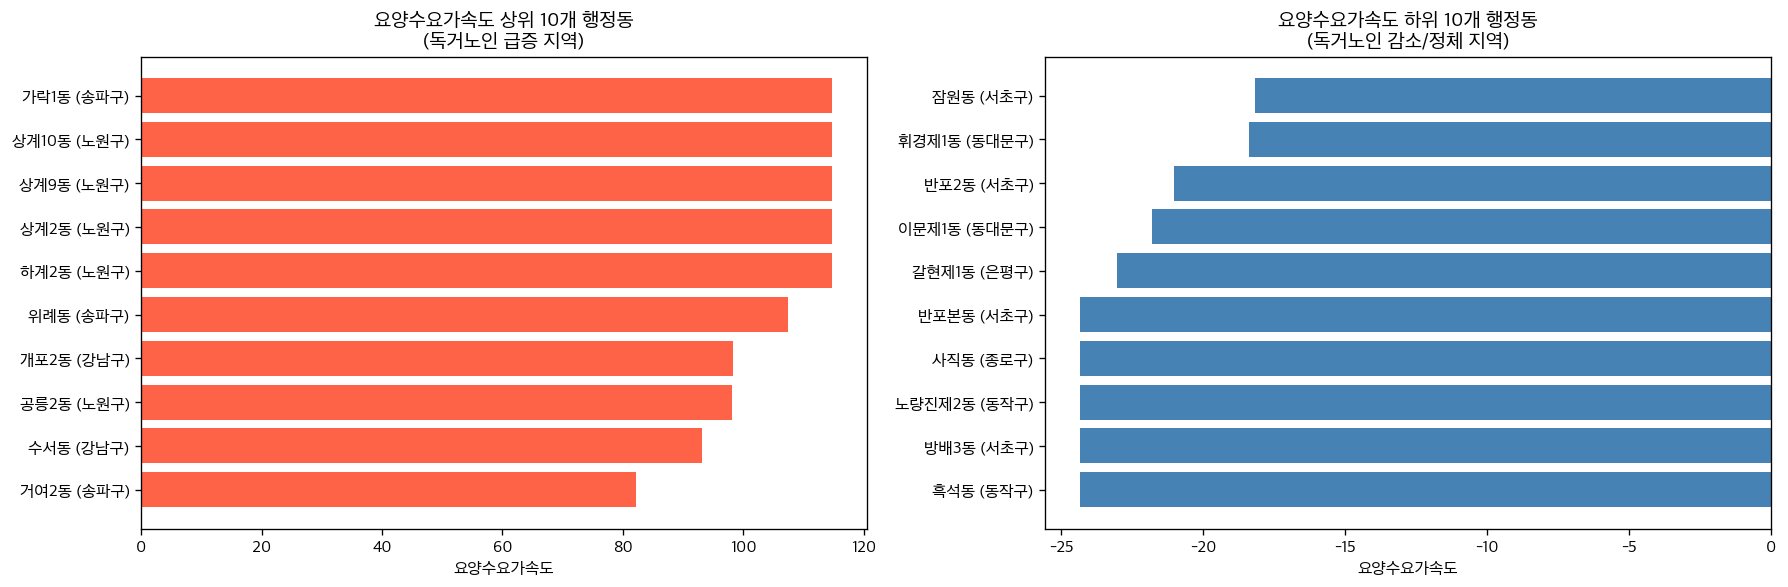

In [62]:
# 상위/하위 10개 행정동 - 확인
df_y = df[['행정동명', '자치구명', TARGET]].dropna().sort_values(TARGET, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top10 = df_y.head(10)
axes[0].barh(top10['행정동명'] + ' (' + top10['자치구명'] + ')',
             top10[TARGET], color='tomato')
axes[0].set_title('요양수요가속도 상위 10개 행정동\n(독거노인 급증 지역)')
axes[0].invert_yaxis()
axes[0].set_xlabel(TARGET)

bot10 = df_y.tail(10)
axes[1].barh(bot10['행정동명'] + ' (' + bot10['자치구명'] + ')',
             bot10[TARGET], color='steelblue')
axes[1].set_title('요양수요가속도 하위 10개 행정동\n(독거노인 감소/정체 지역)')
axes[1].invert_yaxis()
axes[1].set_xlabel(TARGET)

plt.tight_layout()
plt.show()

---
## 3. X 변수 분포 분석 및 이상치 탐지

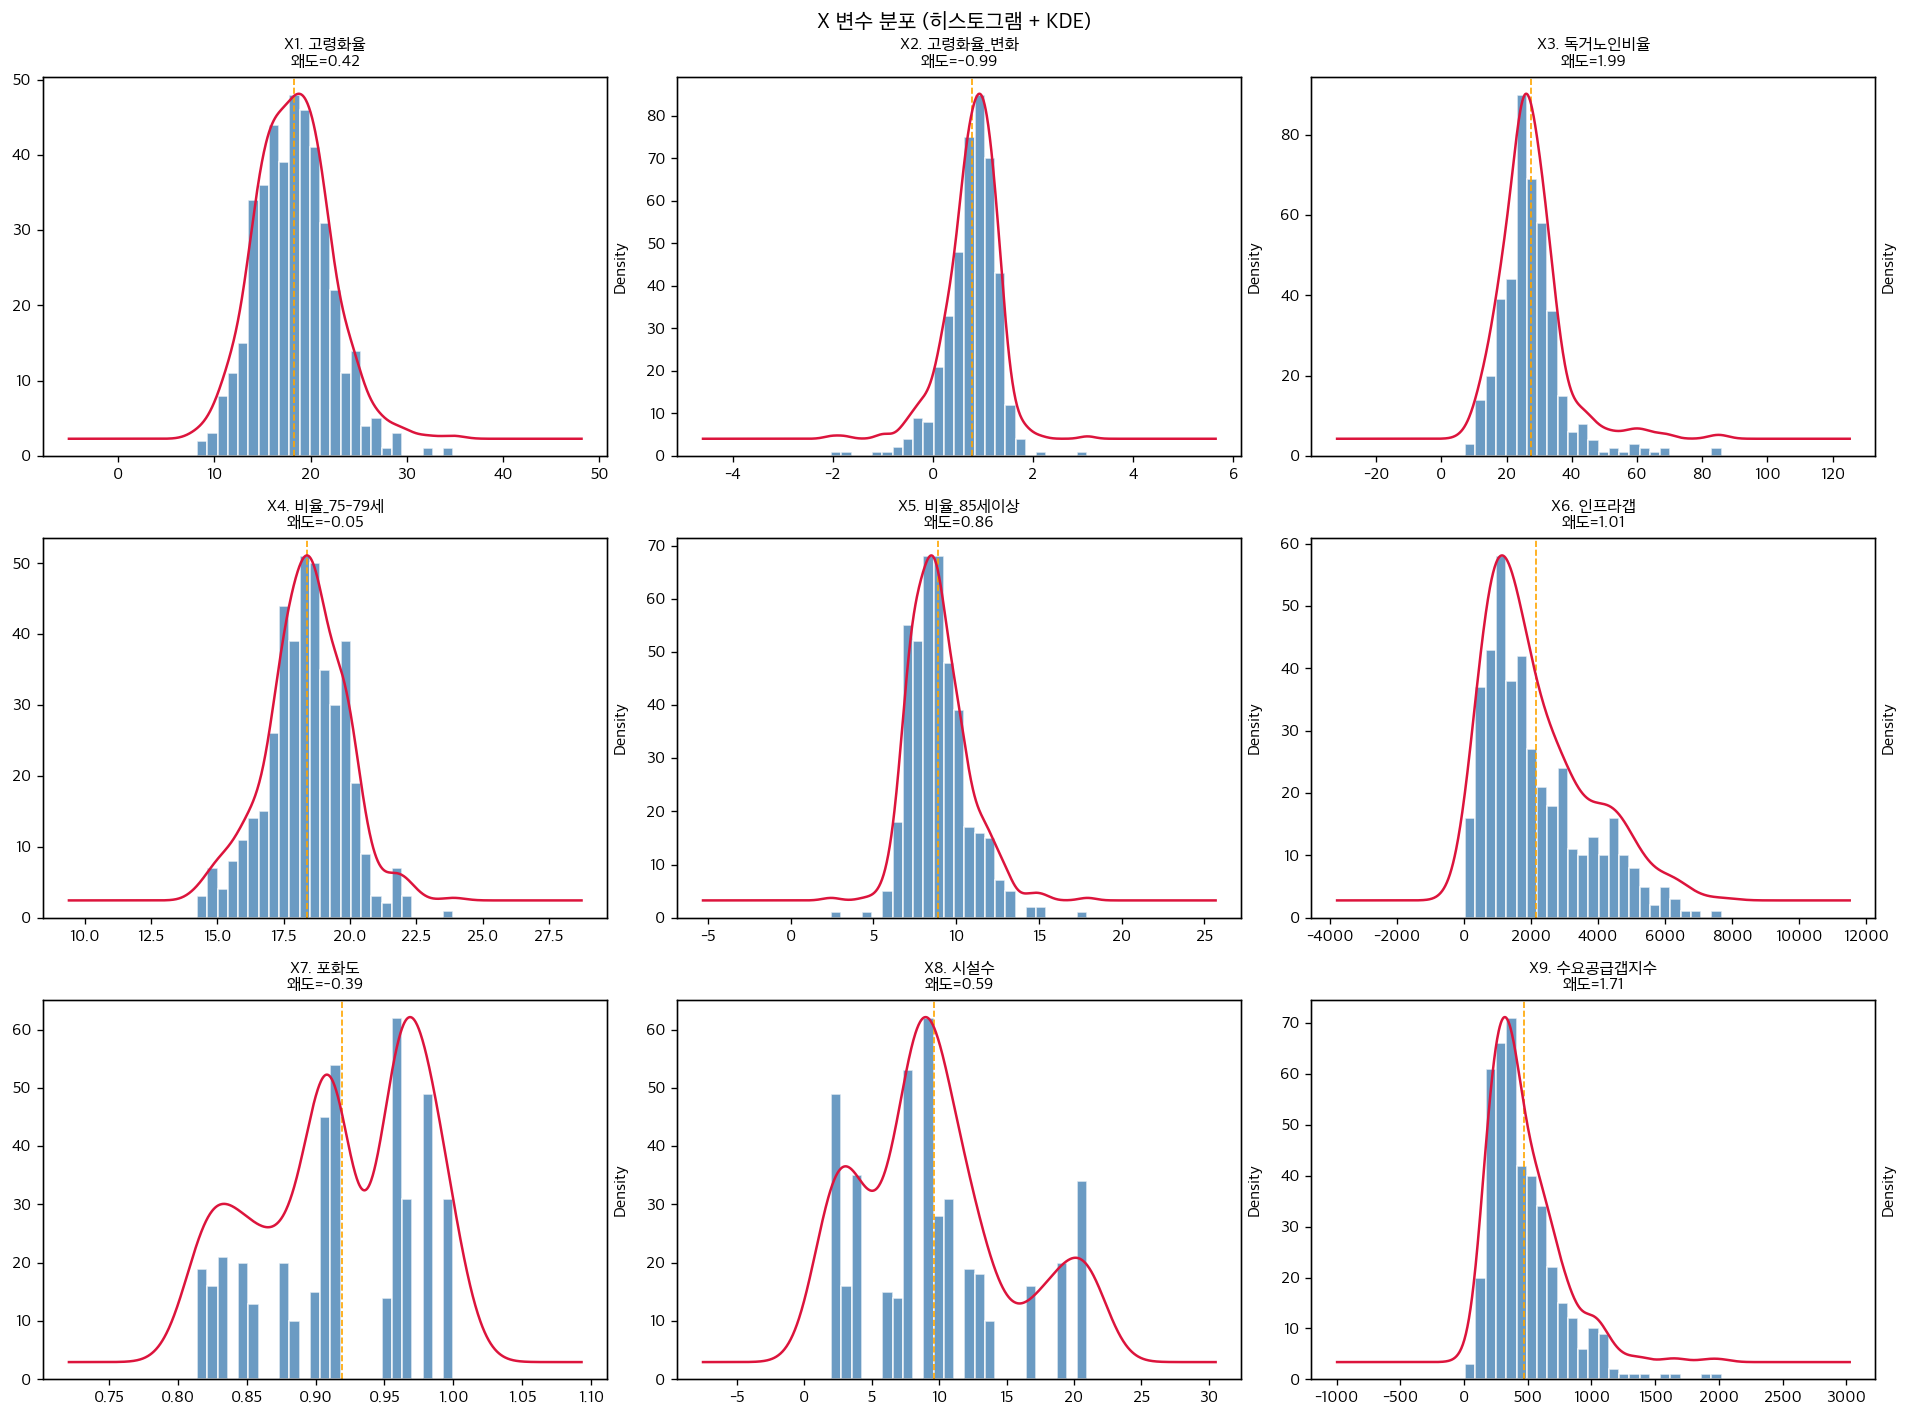

In [63]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(FEAT_COLS):
    series = df[col].dropna()
    axes[i].hist(series, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax_twin = axes[i].twinx()
    series.plot.kde(ax=ax_twin, color='crimson', linewidth=1.5)
    ax_twin.set_yticks([])
    axes[i].axvline(series.mean(), color='orange', linestyle='--', linewidth=1)
    axes[i].set_title(f'X{i+1}. {col}\n왜도={series.skew():.2f}', fontsize=10)

plt.suptitle('X 변수 분포 (히스토그램 + KDE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# IQR 기반 이상치 탐지
outlier_summary = []
for col in FEAT_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({
        '변수': col, 'Q1': round(q1, 2), 'Q3': round(q3, 2),
        '하한': round(lo, 2), '상한': round(hi, 2),
        '이상치수': n_out, '이상치율(%)': round(n_out / len(df) * 100, 1)
    })
pd.DataFrame(outlier_summary).set_index('변수')

=== IQR 기반 이상치 탐지 ===


,Q1,Q3,하한,상한,이상치수,이상치율(%)
변수,,,,,,
고령화율,15.60,20.65,8.02,28.23,5,1.2
고령화율_변화,0.54,1.11,-0.32,1.97,13,3.1
독거노인비율,22.03,31.02,8.55,44.50,20,4.8
비율_75-79세,17.55,19.34,14.86,22.02,9,2.1
비율_85세이상,7.70,9.86,4.47,13.09,8,1.9
인프라갭,1013.70,3000.00,-1965.75,5979.45,11,2.6
포화도,0.88,0.96,0.74,1.10,0,0.0
시설수,6.00,12.00,-3.00,21.00,0,0.0
수요공급갭지수,277.25,613.89,-227.71,1118.85,11,2.6


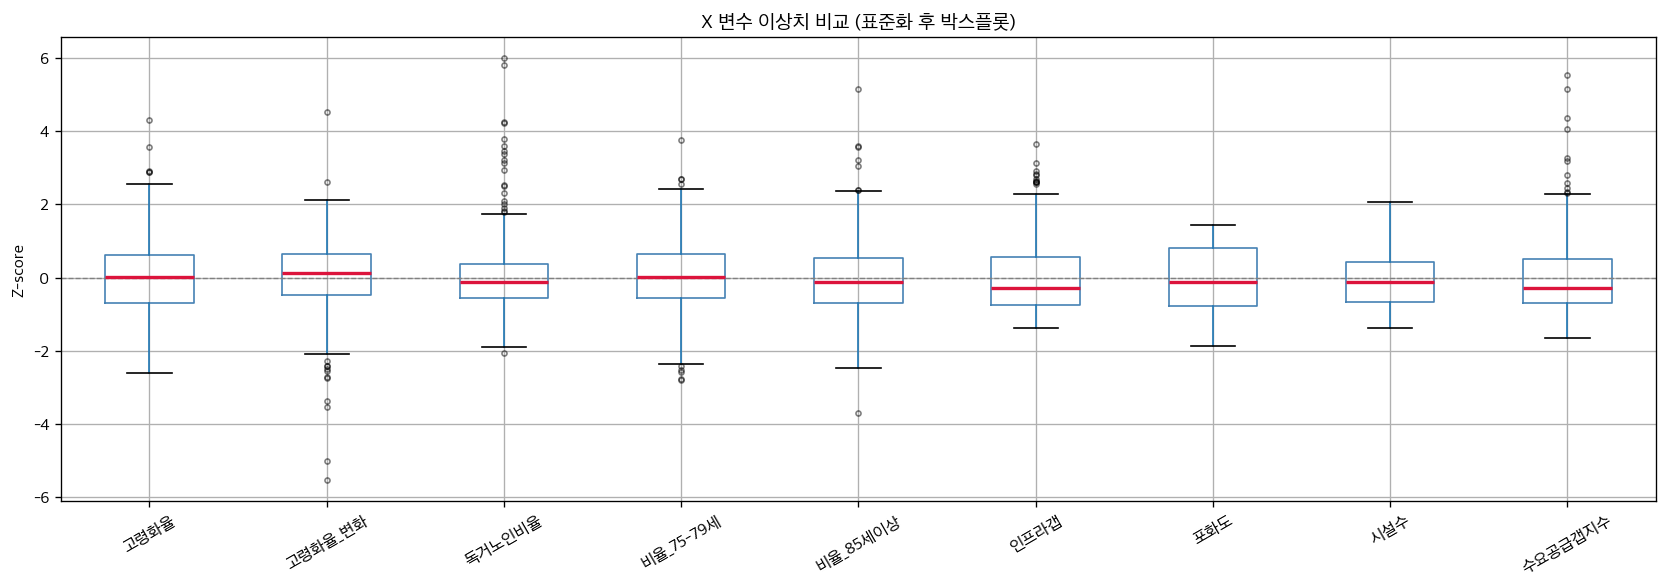

In [65]:
# X 변수 박스플롯 (표준화 후 비교)
from sklearn.preprocessing import StandardScaler

df_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df[FEAT_COLS].dropna()),
    columns=FEAT_COLS
)

fig, ax = plt.subplots(figsize=(14, 5))
df_scaled.boxplot(
    ax=ax, vert=True,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='crimson', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5)
)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('X 변수 이상치 비교 (표준화 후 박스플롯)', fontsize=12)
ax.set_ylabel('Z-score')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 4. 변수 간 상관관계 분석

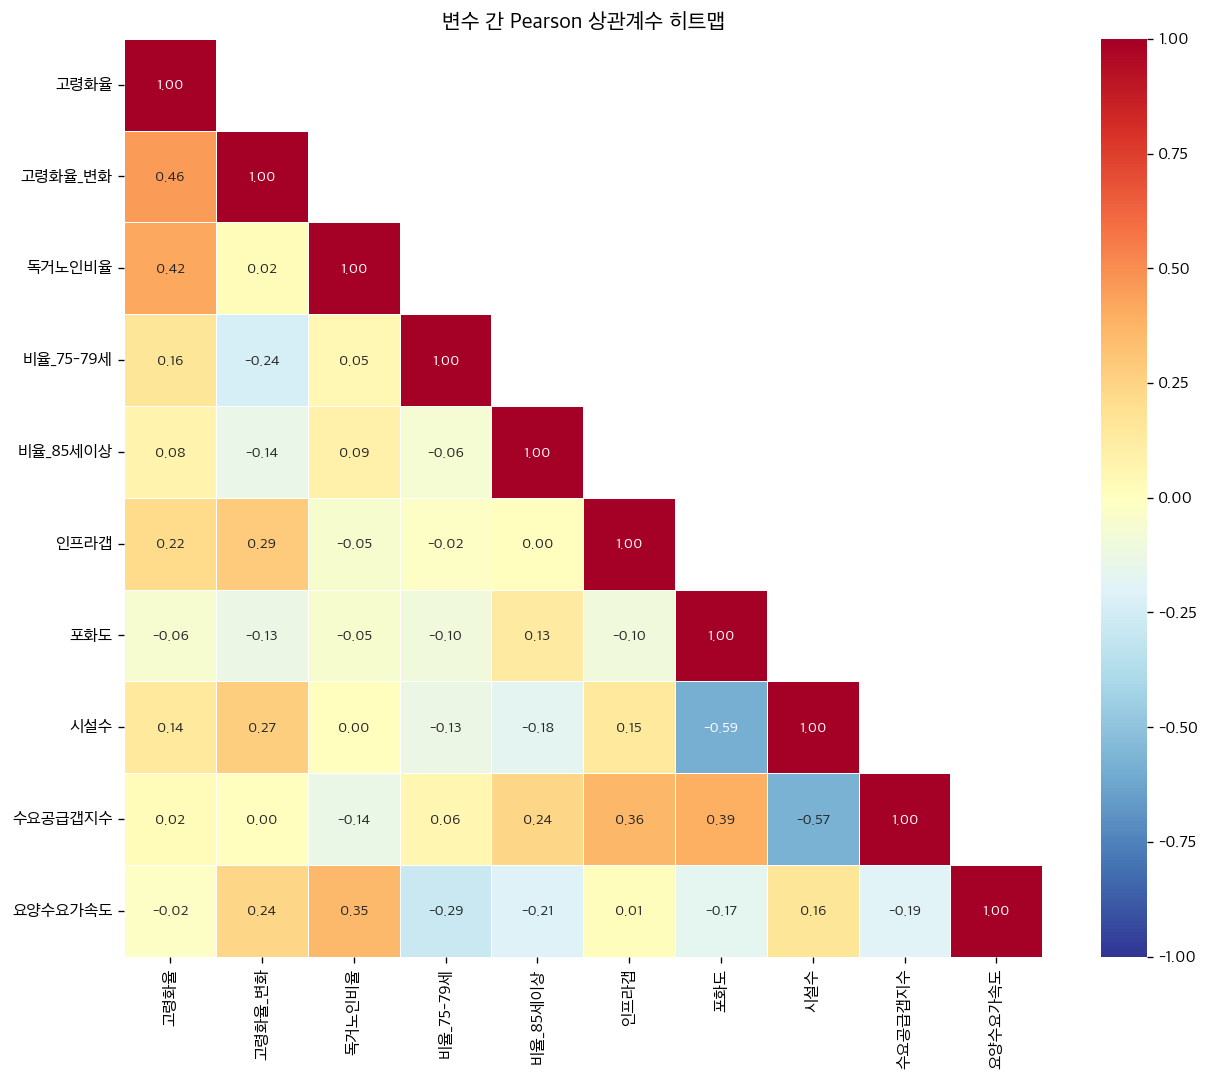


=== Y(요양수요가속도)와의 상관계수 순위 ===
독거노인비율 : 0.353
비율_75-79세 : 0.287
고령화율_변화 : 0.239
비율_85세이상 : 0.208
수요공급갭지수 : 0.193
포화도 : 0.166
시설수 : 0.159
고령화율 : 0.018
인프라갭 : 0.009


In [89]:
# Pearson 상관계수 히트맵 - 변수(X변수 + 타겟 변수(Y))
corr_cols = FEAT_COLS + [TARGET]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdYlBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('변수 간 Pearson 상관계수 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr_y = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('\n=== Y(요양수요가속도)와의 상관계수 순위 ===')
for var, r in corr_y.items():
    print(f'{var} : {abs(r):.3f}')

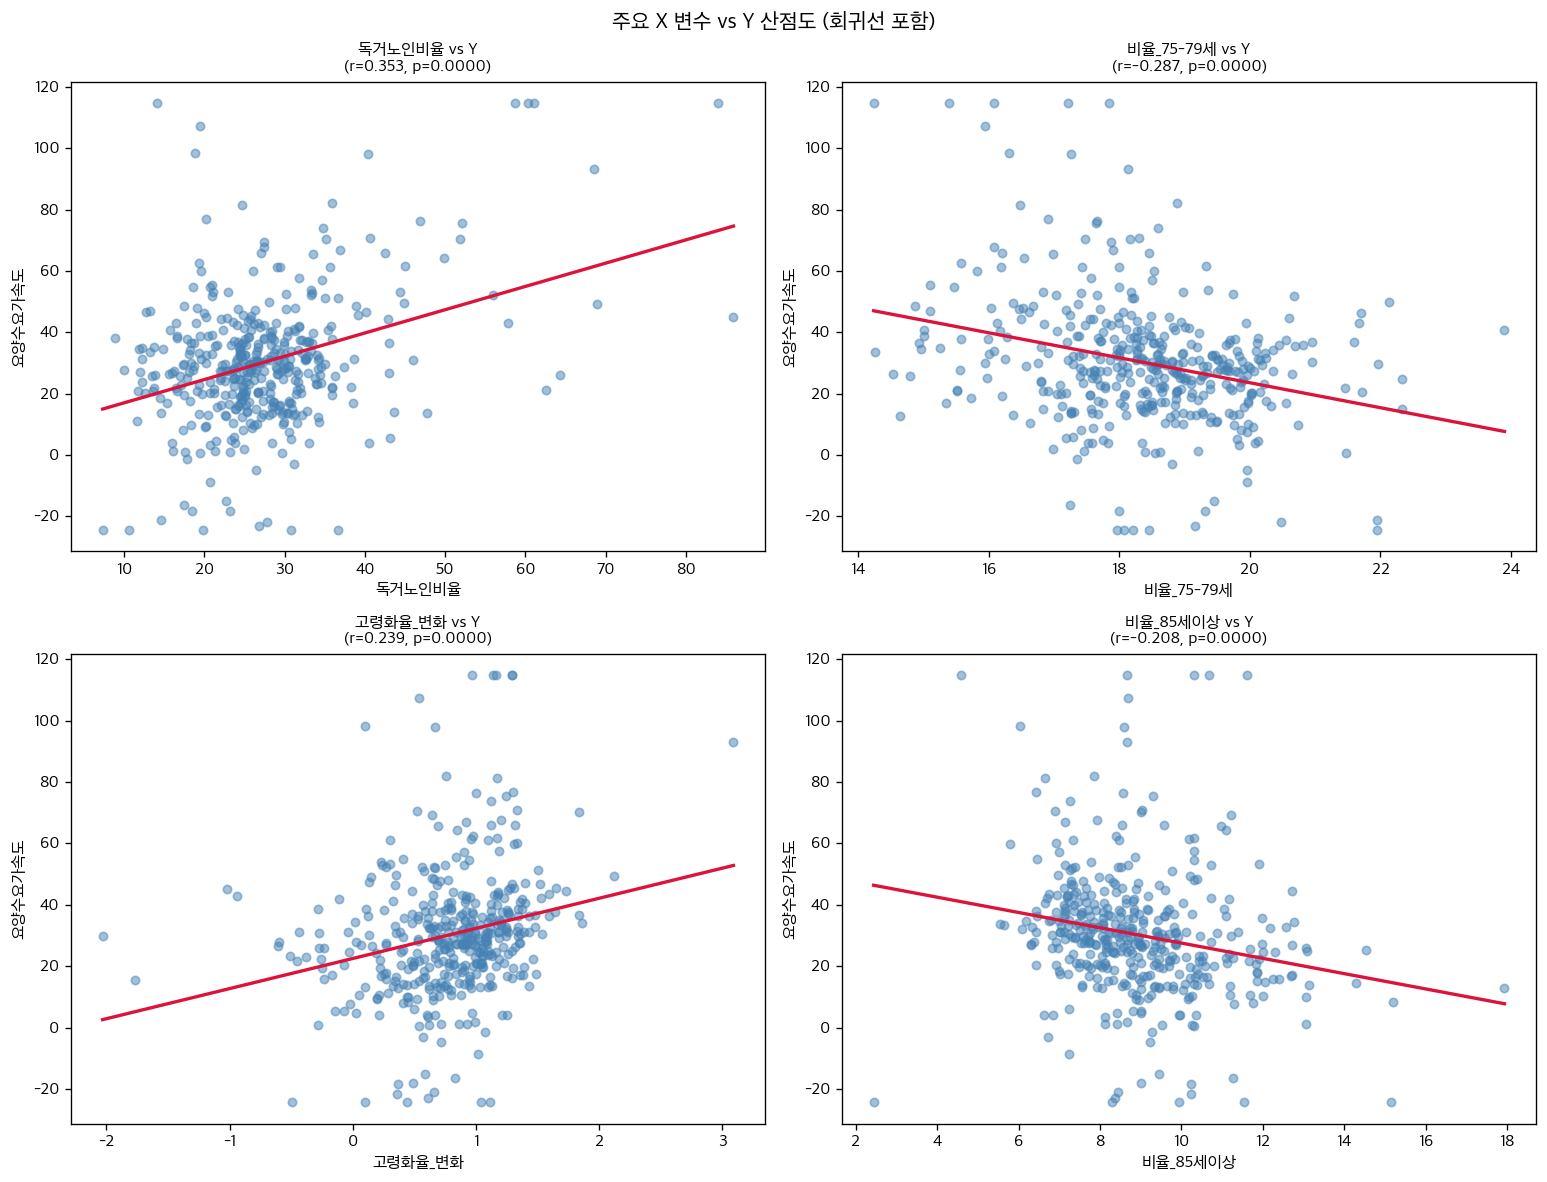

In [67]:
# Y vs 주요 X 변수 산점도 (상관 상위 4개)
top4_vars = corr_y.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(top4_vars):
    x_vals = df[col]
    y_vals = df[TARGET]
    mask = x_vals.notna() & y_vals.notna()
    slope, intercept, r, p, _ = stats.linregress(x_vals[mask], y_vals[mask])

    axes[i].scatter(x_vals[mask], y_vals[mask], alpha=0.5, s=25, color='steelblue')
    x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
    axes[i].plot(x_line, slope * x_line + intercept, color='crimson', linewidth=2)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f'{col} vs Y\n(r={r:.3f}, p={p:.4f})', fontsize=10)

plt.suptitle('주요 X 변수 vs Y 산점도 (회귀선 포함)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. ML 트랙별 준비 상태 확인

### 5-A. 트랙 A (회귀) — Y 전처리 방향 확인

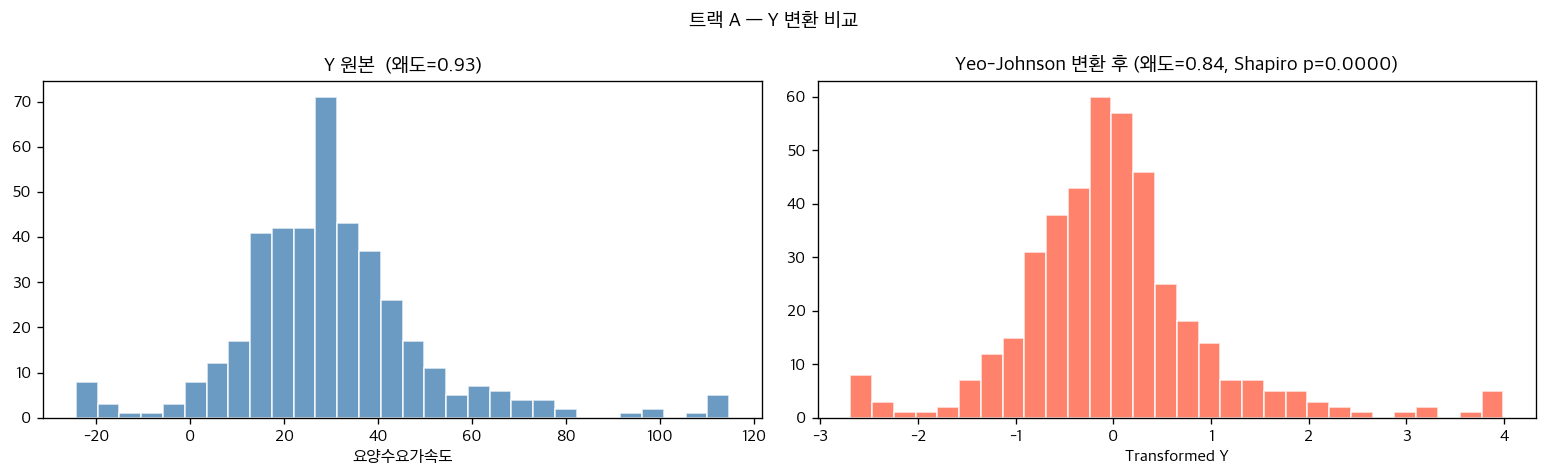

원본 왜도: 0.932
Yeo-Johnson 왜도: 0.843

==변환 진행 선택 결정==
변환 진행 X


In [90]:
from sklearn.preprocessing import PowerTransformer

y_vals = df[TARGET].dropna()
pt = PowerTransformer(method='yeo-johnson')
y_transformed = pt.fit_transform(y_vals.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_vals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Y 원본  (왜도={y_vals.skew():.2f})')
axes[0].set_xlabel(TARGET)

stat_sw2, p_sw2 = stats.shapiro(y_transformed[:5000])
axes[1].hist(y_transformed, bins=30, color='tomato', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Yeo-Johnson 변환 후 (왜도={pd.Series(y_transformed).skew():.2f}, Shapiro p={p_sw2:.4f})')
axes[1].set_xlabel('Transformed Y')

plt.suptitle('트랙 A — Y 변환 비교', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

ori_skew = y_vals.skew()
yeo_skew = pd.Series(y_transformed).skew()

print(f'원본 왜도: {ori_skew:.3f}')
print(f'Yeo-Johnson 왜도: {yeo_skew:.3f}')
print()
print('==변환 진행 선택 결정==')
print('변환 진행' if yeo_skew > 1.0 else '변환 진행 X')


### 5-B. 트랙 B (분류) — IMD 기반 위험등급 라벨

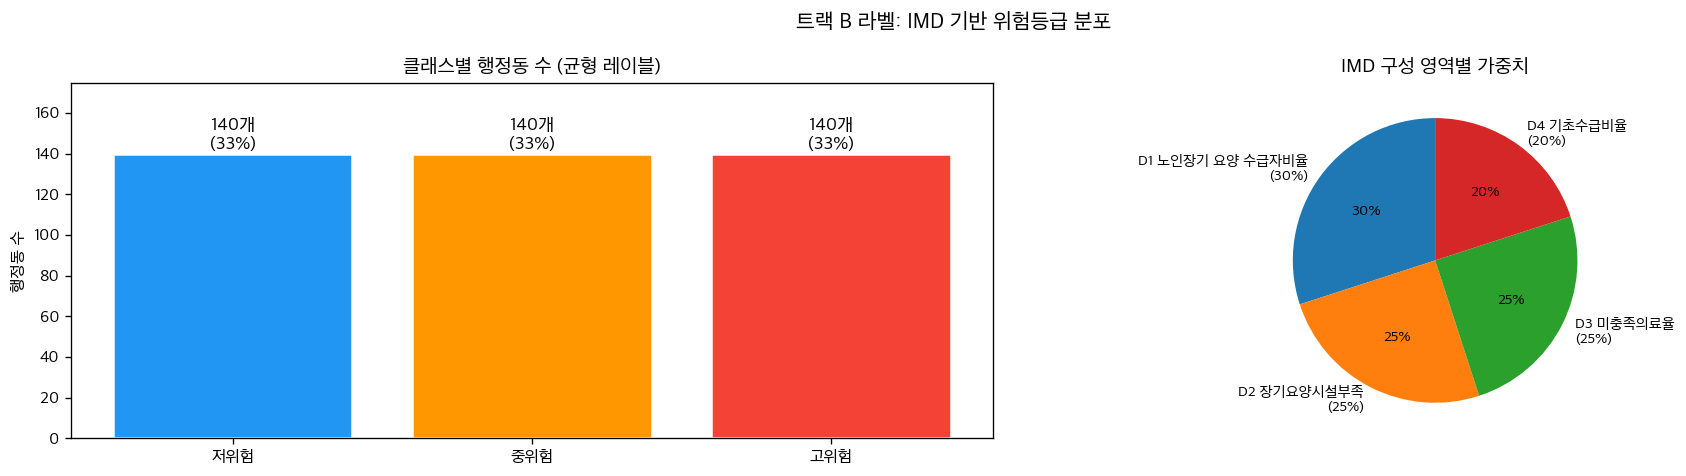

병합 완료: 420개 행정동
클래스 분포: {'중위험': np.int64(140), '저위험': np.int64(140), '고위험': np.int64(140)}

IMD_score 클래스별 요약:
      count  mean   std   min   25%   50%   75%    max
위험등급                                                  
저위험   140.0  0.79  0.15  0.22  0.74  0.82  0.89   0.96
중위험   140.0  1.21  0.19  0.96  1.05  1.16  1.33   1.61
고위험   140.0  4.60  7.88  1.61  1.79  2.10  2.42  60.96


In [92]:
# df_criteria.csv: track2_criteria.ipynb에서 생성된 IMD 기반 위험등급 라벨
# - D1 노인장기요양 수급자 비율 (30%), 
# - D2 요양시설 접근성 (25%)
# - D3 미충족 의료율 (25%)
# - D4 기초수급 비율 (20%)
# - 3분위 균등 분류: 저위험/중위험/고위험 각 140개
dc = pd.read_csv('data/df_criteria.csv', encoding='utf-8-sig', dtype={'행정동코드': str})
df['행정동코드_str'] = df['행정동코드'].astype(str).str.zfill(10)

# 섹션 6에서 생성된 위험등급(Y 분위수 기반)은 IMD 기반으로 교체
df_b = df.drop(columns=['위험등급'], errors='ignore').merge(
    dc[['행정동코드', '위험등급', 'IMD_score',
        'D1_수급자비율', 'D2_시설부족', 'D3_미충족의료율', 'D4_수급비율(2024)']],
    left_on='행정동코드_str', right_on='행정동코드', how='inner'
)

order = ['저위험', '중위험', '고위험']
colors = {'저위험': '#2196F3', '중위험': '#FF9800', '고위험': '#F44336'}
counts = df_b['위험등급'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 클래스 분포 막대
axes[0].bar(order, [counts.get(c, 0) for c in order],
            color=[colors[c] for c in order], edgecolor='white', linewidth=1.5)
for i, c in enumerate(order):
    axes[0].text(i, counts.get(c, 0) + 1, f"{counts.get(c, 0)}개\n({counts.get(c, 0)/len(df_b)*100:.0f}%)",
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('클래스별 행정동 수 (균형 레이블)')
axes[0].set_ylim(0, 175)
axes[0].set_ylabel('행정동 수')


# D1~D4 구성 지표 가중치 파이차트
d_labels = ['D1 노인장기 요양 수급자비율\n(30%)',
            'D2 장기요양시설부족\n(25%)',
            'D3 미충족의료율\n(25%)',
            'D4 기초수급비율\n(20%)']
d_weights = [0.30, 0.25, 0.25, 0.20]
axes[1].pie(d_weights, labels=d_labels,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title('IMD 구성 영역별 가중치')

plt.suptitle('트랙 B 라벨: IMD 기반 위험등급 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'병합 완료: {len(df_b)}개 행정동')
print(f'클래스 분포: {dict(counts)}')
print()
print('IMD_score 클래스별 요약:')
print(df_b.groupby('위험등급')['IMD_score'].describe().round(2).loc[order])


### 5-C. 트랙 C (군집화) — 클러스터 가능성 탐색

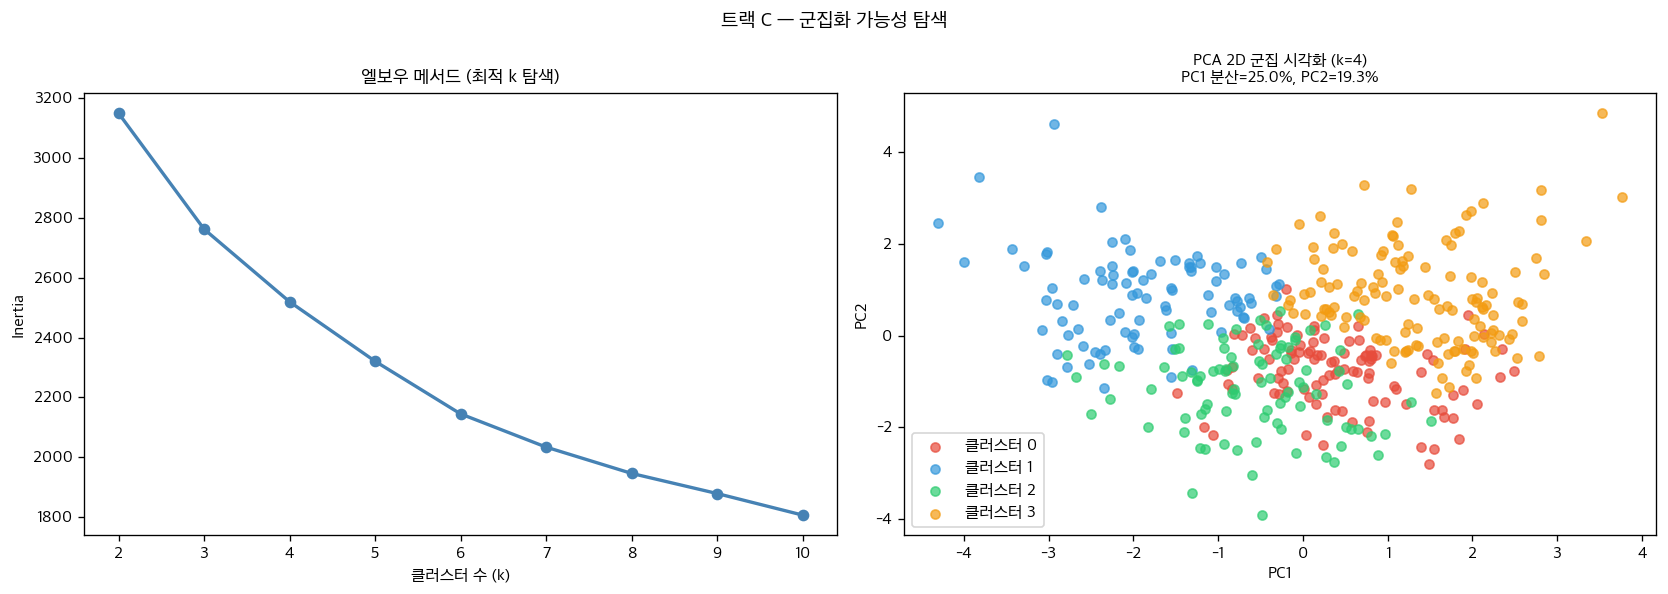

PCA 누적 설명 분산 (2개 PC): 44.3%


In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

df_feat = df[FEAT_COLS].dropna()
X_scaled = StandardScaler().fit_transform(df_feat)

# 엘보우 메서드
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('엘보우 메서드 (최적 k 탐색)', fontsize=11)
axes[0].set_xlabel('클러스터 수 (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

# PCA 2D + KMeans k=4
BEST_K = 4
km_best = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
for c in range(BEST_K):
    mask = cluster_labels == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette[c], label=f'클러스터 {c}', s=30, alpha=0.7)

axes[1].set_title(
    f'PCA 2D 군집 시각화 (k={BEST_K})\n'
    f'PC1 분산={pca.explained_variance_ratio_[0]:.1%}, '
    f'PC2={pca.explained_variance_ratio_[1]:.1%}', fontsize=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('트랙 C — 군집화 가능성 탐색', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PCA 누적 설명 분산 (2개 PC): {sum(pca.explained_variance_ratio_):.1%}')

In [73]:
# 클러스터별 변수 평균 — 클러스터 해석
df_cluster = df_feat.copy()
df_cluster['클러스터'] = cluster_labels
df_cluster[TARGET] = df.loc[df_feat.index, TARGET].values

print('=== 클러스터별 변수 평균 ===')
df_cluster.groupby('클러스터').mean().round(2)

=== 클러스터별 변수 평균 ===


,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_85세이상,인프라갭,포화도,시설수,수요공급갭지수,요양수요가속도
클러스터,,,,,,,,,,
0,15.96,0.92,22.15,17.14,7.96,1663.65,0.92,11.42,349.26,37.95
1,18.16,0.71,25.33,18.28,10.19,2355.37,0.97,3.73,855.31,19.79
2,16.44,0.21,29.46,19.55,9.05,1141.65,0.92,7.64,341.62,24.66
3,21.41,1.12,31.59,18.62,8.76,3090.76,0.88,13.58,402.61,34.83


### EDA 종합 요약

- 데이터 : 서울시 420개 행정동 × 19개 컬럼 (2023 단면)
- 결측치 : 없음 

---

[Y 변수] 요양수요가속도
- 범위     -24.3 ~ 114.8
- 평균     30.20  |  중앙값: 28.83
- 왜도     0.932  |  Shapiro p: 0.0000

---
[X 변수] Y와 가장 높은 상관 (상위 3개)
- 독거노인비율  : r = +0.353
- 비율_75-79세 : r = -0.287
- 고령화율_변화 : r = +0.239

---

[트랙 A] 회귀
- VIF 전원 < 3 (다중공선성 문제 없음)
- Y 왜도 크므로 Yeo-Johnson 변환 검토 (왜도 0.93 → 0.84로 효과 미미 → 원본 사용 후 잔차 진단으로 최종 결정)

---

[트랙 B] 분류
- Y 라벨 : IMD 기반 위험등급 (저위험/중위험/고위험 각 140개, 균형 레이블)
- 라벨 구성 : D1 수급자비율(30%) + D2 시설부족(25%) + D3 미충족의료율(25%) + D4 수급비율(20%)
- 도메인 간 최대 상관 0.238 → 독립적 정보 제공 확인
- 클래스 완전 균형 → SMOTE 불필요
- 전처리 방향 : RobustScaler 권장
  - 이상치가 존재하지만 제거하기에 어려움이 있어서 완화시키는 방향으로 진행.

---

[트랙 C] 군집화 - (예상)
- 권장 k : 4 (엘보우 메서드 기반)
- 전처리 : StandardScaler 필수 (인프라갭 범위 41~7,688 vs 포화도 0.81~1.00)
- 클러스터 해석
  - Cluster 0 : 급성장 잠재위험 — 고령화율 낮으나 요양수요가속도 최고(37.95), 인프라 현재 여유
  - Cluster 1 : 즉각 대응 필요 — 시설수 최소(3.73개), 포화도 0.97, 수요공급갭 최대(855)
  - Cluster 2 : 안정형 — 고령화율_변화 최소(0.21), 인프라갭 최소(1,142), 수요 증가 완만
  - Cluster 3 : 구조적 고위험 — 고령화율 최고(21.4), 독거노인비율 최고(31.6), 인프라갭 최대(3,091)

---
